# Project: Reinforcement Learning Pair Trading: A Dynamic Scaling Approach
### Group Members
#### Manish Patturu (Student ID - 12454918)
#### Pratyush Kalli (Student ID - 12459436)
#### Satyam Saurabh (Student ID - 12452991)
#### Abhay Kanwar (Student ID - 12457992)
#### Shayan Choudhury (Student ID - 12455354)

## Content
### 0. Abstract
### 1. Keywords
### 2. Introduction
### 3. Data
### 4. Techniques and Theory Details in the Strategy
### 5. Citation and other Resources

### 0. Abstract  
  
Daily trading volumes of Cryptocurrencies reaches around tens of billions of USD. Their unpredictable nature makes algorithmic trading a challenging endeavor. This work explores whether reinforcement learning can drive more effective decision-making in cryptocurrency trading than traditional, rule-based methods.  
  
The approach merges reinforcement learning with a statistical arbitrage strategy known as pair trading, which capitalizes on price discrepancies between correlated assets. Custom reward mechanisms and specialized observation/action spaces were designed to guide agents on when and how to execute trades. We empirically evaluate 5 pais (like BTC-USD, ETH-USD etc) at one-minute intervals on one year time period i.e., over more than 500,000 data points.

### 1. Keywords  
  
- Pair Trading
- Reinforcement Learning (RL)
- Dynamic Scaling
- Cryptocurrency Market
- Statistical Arbitrage
- A2C, PPO, SAC
- Correlation and Cointegration
- High-Frequency Trading

### 2. Introduction  
  
Machine learning spans a wide range of fields in the real world — finance, robotics, computer vision, medicine, and more. In this project, we leverage a specialized branch of machine learning known as reinforcement learning, incorporating it into our trading methodology. Reinforcement learning, which belongs to the broader domain of artificial intelligence, allows software agents to autonomously determine optimal actions within a given environment by maximizing cumulative rewards. Critically, these rewards serve as feedback signals that guide the agent’s behavioral updates. Through repeated interactions with its environment, the agent refines its decision-making rules over time. As a result, with careful modeling, reinforcement learning can approximate or converge to globally optimal solutions for well-defined tasks. Much like the way humans learn by trial and error, these agents gather experiences, adjust their strategies, and increasingly improve their ability to identify profitable patterns and opportunities.  
  
A key motivation for adopting reinforcement learning in our trading workflow is the ability to incorporate newly updated market data in near real time, reducing the risk of overfitting to historical conditions. This dynamic feedback loop stands in contrast to many traditional machine learning approaches, where models are primarily trained offline on past observations. A widely recognized demonstration of reinforcement learning’s adaptability can be seen in advanced robotics, where control policies are refined purely through trial-and-error in real or simulated environments. This same capacity to learn incrementally translates well to financial markets: a trading agent equipped with reinforcement learning can continuously adjust to new market information, improving its strategies for determining when and how to enter or exit trades.  

In particular, our project employs a model-free algorithmic framework that learns action values by directly interacting with market states rather than relying on a pre-defined market model. This setup involves defining a finite Markov decision process (MDP), where each state–action pair is associated with an expected return value. The agent incrementally refines these values, and once an accurate mapping from state–action pairs to returns is established, the agent’s policy becomes simply selecting the action that maximizes the learned value in each scenario. This versatility suits dynamic and complex trading environments, ensuring that the agent can exploit evolving market patterns and adapt its behavior to optimize gains over time.  
  
In traditional finance, pair trading has long been regarded as a market-neutral arbitrage strategy. A common approach is to identify two assets with high historical correlation and/or cointegration; when their price difference (spread) deviates beyond a certain threshold, trades are opened in opposite directions, anticipating that the spread will revert. However, rule-based pair trading can be inflexible, especially in highly volatile markets such as cryptocurrencies.  
  
Our project expands on existing statistical arbitrage methods with reinforcement learning. By framing the financial market as a Markov Decision Process (MDP), we design RL agents to learn when to open or close positions and how much capital to allocate. Leveraging dynamic scaling within pair trading—i.e., investing in variable sizes rather than a fixed fraction—addresses market regimes of varying volatility and potential profitability.

### 3. Data  

A major goal of our project is to showcase the potential of our reinforcement learning approach in a fast-paced environment where price movements can be sudden and significant. After a bit of research, we turned to cryptocurrency markets, which are renowned for high liquidity and rapid price swings. To further ensure that our trading strategy could handle varying degrees of volatility, we focused on four stable crypto–fiat pairs—BTC-USD, ETH-USD, LTC-USD, FTM-USD and XRP-USD—given their large daily trading volumes on prominent exchanges.   
  
We collected historical price data from Kaggle (an online platform for data science and machine learning that offers datasets, competitions, and a collaborative community for data practitioners). The data is extracted over a one-year period, from 01-07-2022 to 30-06-2023, at one-minute intervals to capture as many market fluctuations as possible. Notably, Kaggle logs activity only for the minutes when at least one trade has occurred; minutes with no trades remain blank. Consequently, after downloading the raw data, we forward-filled missing entries to maintain continuity in the time series, then merged all records into a single DataFrame. This final dataset indexed every minute in the specified date range and contained price and volume data for the four chosen cryptocurrencies as columns. The result was a unified collection of more than 500,000 time-stamped rows, capturing both routine and extraordinary market conditions. By preserving a consistent time granularity, this refined dataset provided a robust foundation for observing how reinforcement learning agents react to sudden changes in crypto prices over short trading windows.

In [32]:
import importlib
import cmds.data_loading

importlib.reload(cmds.data_loading)  # Forces re-import of the updated code

from cmds.data_loading import *

In [34]:
# Only providing preprocessed files in the zip. so the above cell will not work, but the below cells will work without errors
# Already ran in local and data populated

# create_preprocessed_data()

In [36]:
verify_rows()

Filtered btcusd_preprocessed.csv has 525601 rows
Filtered ethusd_preprocessed.csv has 525601 rows
Filtered xrpusd_preprocessed.csv has 525601 rows
Filtered ltcusd_preprocessed.csv has 525601 rows
Filtered ftmusd_preprocessed.csv has 525601 rows


In [38]:
merged_df = create_merged_df()
merged_df.tail()

,time,open_btc,close_btc,high_btc,low_btc,volume_btc,open_eth,close_eth,high_eth,low_eth,...,close_ltc,high_ltc,low_ltc,volume_ltc,open_ftm,close_ftm,high_ftm,low_ftm,volume_ftm,Unnamed: 0
525596,2023-06-30 23:56:00,30504.0,30504.0,30504.0,30504.0,0.000000,1935.5,1935.0,1935.5,1935.0,...,108.45,108.67,108.33,2.180289,0.30445,0.30445,0.30445,0.30445,0.0,NaN
525597,2023-06-30 23:57:00,30497.0,30501.0,30501.0,30497.0,0.010000,1934.5,1934.5,1934.5,1934.5,...,108.34,108.46,108.29,0.550000,0.30445,0.30445,0.30445,0.30445,0.0,NaN
525598,2023-06-30 23:58:00,30500.0,30500.0,30500.0,30500.0,0.036400,1934.9,1934.9,1934.9,1934.9,...,108.45,108.45,108.25,1.100000,0.30445,0.30445,0.30445,0.30445,0.0,NaN
525599,2023-06-30 23:59:00,30500.0,30500.0,30500.0,30500.0,0.000000,1936.2,1936.2,1936.2,1936.2,...,108.70,108.75,108.62,16.736159,0.30445,0.30445,0.30445,0.30445,0.0,NaN
525600,2023-07-01 00:00:00,30499.0,30506.0,30506.0,30499.0,0.083749,1935.9,1936.8,1936.8,1935.9,...,108.96,108.97,108.77,25.181008,0.30503,0.30553,0.30553,0.30503,30000.0,NaN


In [40]:
# Display summary statistics for each crypto's closing price
print("Summary statistics for closing prices:")
merged_df[["close_btc", "close_eth", "close_xrp", "close_ftm", "close_ltc"]].describe()

Summary statistics for closing prices:


,close_btc,close_eth,close_xrp,close_ftm,close_ltc
count,525601.000000,525601.000000,525601.000000,525601.000000,525601.000000
mean,22523.321878,1564.885292,0.413704,0.324701,74.013623
std,4136.167089,256.058427,0.061377,0.106142,16.098769
min,15510.000000,1012.500000,0.303490,0.164660,46.511000
25%,19311.000000,1312.400000,0.365800,0.234250,57.708000
50%,22005.000000,1592.900000,0.393610,0.302010,76.450000
75%,26540.000000,1793.500000,0.468340,0.409910,89.184000
max,31414.000000,2124.000000,0.582090,0.653510,111.330000


In [42]:
# Display summary statistics for each crypto's volume
print("Summary statistics for volume:")
merged_df[["volume_btc", "volume_eth", "volume_xrp", "volume_ftm", "volume_ltc"]].describe()

Summary statistics for volume:


,volume_btc,volume_eth,volume_xrp,volume_ftm,volume_ltc
count,525601.000000,525601.000000,5.256010e+05,5.256010e+05,525601.000000
mean,2.316610,15.540886,5.348910e+03,3.085297e+02,12.264346
std,13.891756,95.719962,2.885339e+04,5.541026e+03,129.405164
min,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000
25%,0.013558,0.042830,2.400000e+01,0.000000e+00,0.000000
50%,0.182941,0.763640,3.476241e+02,0.000000e+00,0.060506
75%,0.893410,5.730452,2.277262e+03,7.950301e+00,1.390992
max,1887.795992,10125.314406,2.638403e+06,1.747559e+06,41346.652746


In [44]:
corr_matrix = get_correlation_matrix(merged_df)
corr_matrix

Correlation matrix among closing prices:


,close_btc,close_eth,close_ltc,close_ftm,close_xrp
close_btc,1.000000,0.913568,0.614551,0.701181,0.589107
close_eth,0.913568,1.000000,0.597682,0.696669,0.516774
close_ltc,0.614551,0.597682,1.000000,0.730936,0.379692
close_ftm,0.701181,0.696669,0.730936,1.000000,0.202807
close_xrp,0.589107,0.516774,0.379692,0.202807,1.000000


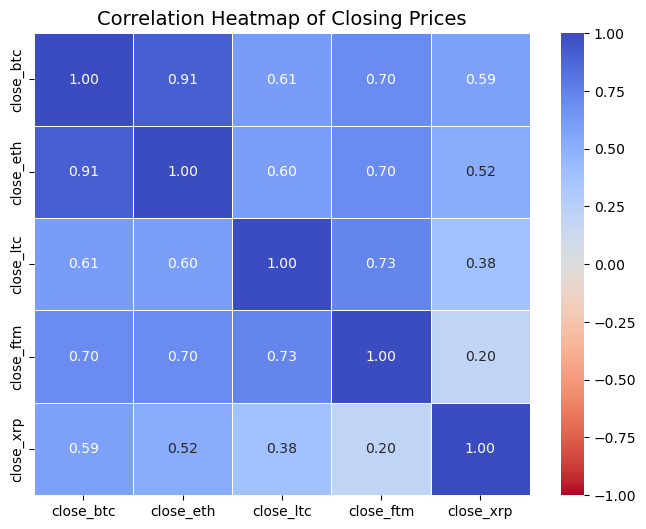

In [46]:
create_heat_map(corr_matrix)

#### Lets consider 5 pairs btc-eth, btc-ltc, btc-xrp, eth-ltc, eth-ftm

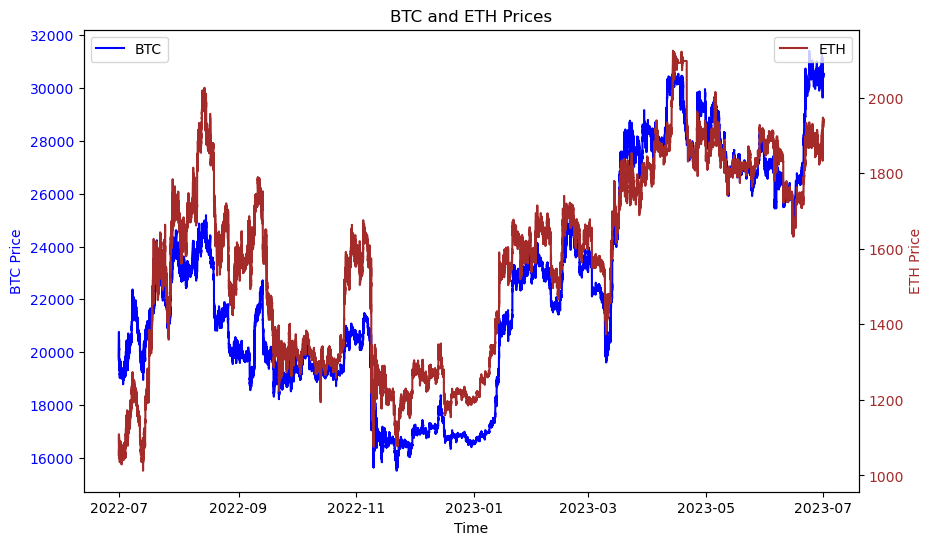

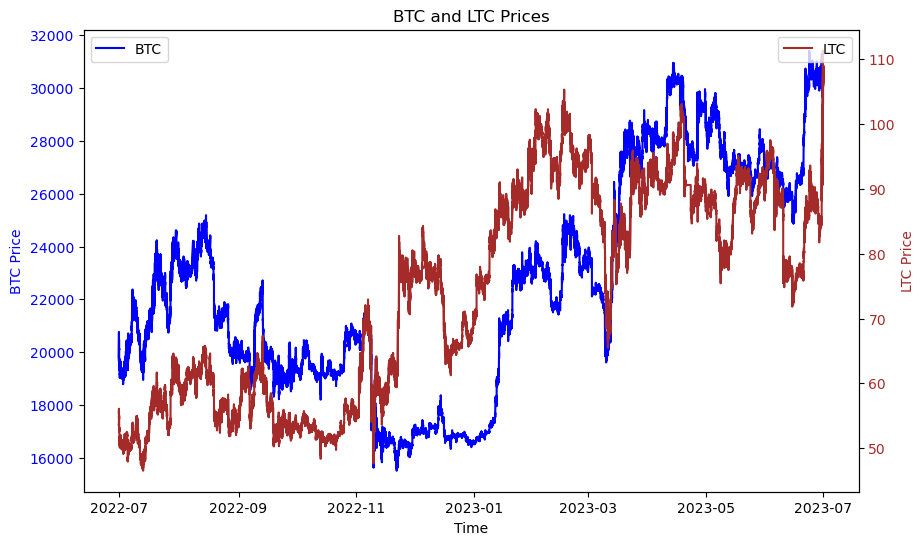

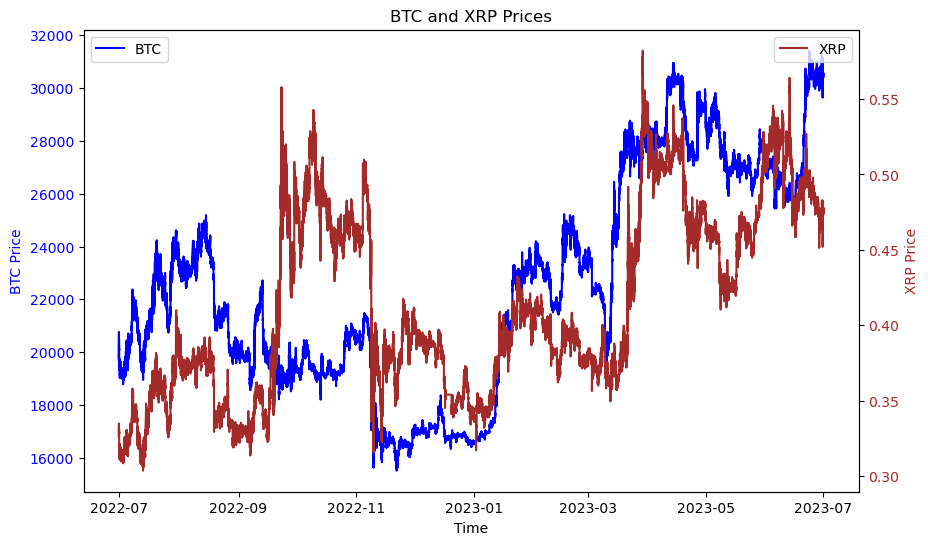

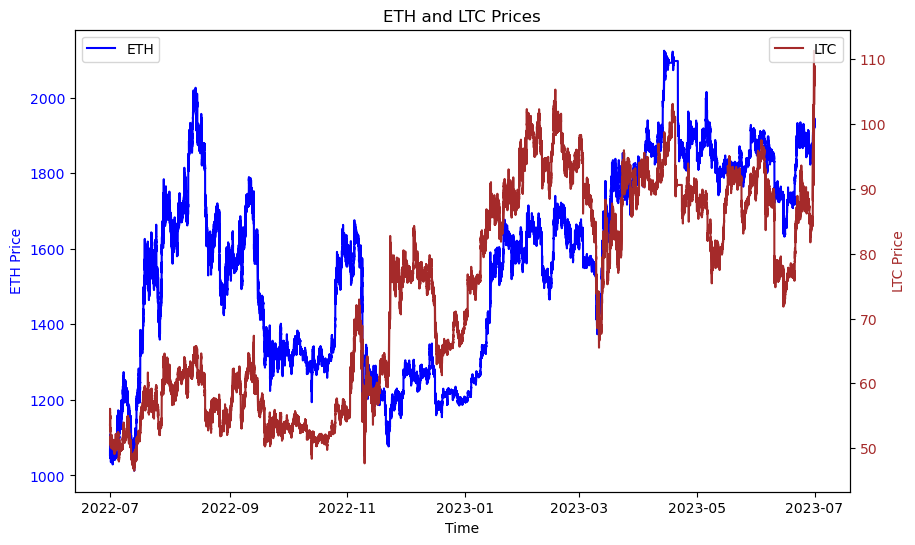

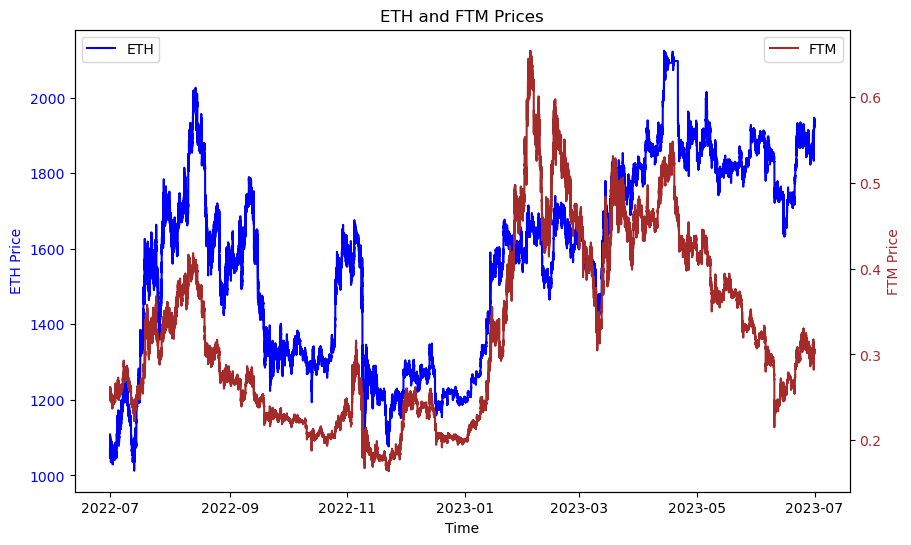

In [49]:
create_plots(merged_df)

### 4. Techniques and Theory Details in the Strategy  

#### 4.1 Pair Trading Basics  
**Definition**: Pair trading involves going long on one asset and short on the other if the spread between them diverges significantly from historical averages.  
  
**Spread Modeling**: The project normalizes the spread with a Z-score, capturing deviations relative to the current mean and volatility.  
*Linear Regression for Spread Calculation*

Suppose we have two asset price series \( $p_x$(t) \) and \( $p_y$(t) \). A common step is to perform a simple linear regression,

$$
p_x(t) = \alpha + \beta * p_y(t) + \epsilon_t
$$

where \($\alpha$) and \($\beta$) are regression coefficients and \($\epsilon_t$) is the residual term at time \(t\). We then defines the spread \($s_t$) as

$$
s_t = p_x(t) - \left(\alpha + \beta\, p_y(t)\right).
$$

Intuitively, \($\beta$) captures how \($p_x$) scales with changes in \($p_y$). If \($\beta$) is close to \(1\), then \($p_x$) and \($p_y$) move similarly in magnitude, whereas a higher or lower \($\beta$) indicates different volatility characteristics. After fitting \($\alpha$) and \($\beta$) to historical data, the residual \($\epsilon_t$) ideally reflects a mean-reverting process—one that oscillates around zero.

**Z-Score Normalization**  
  
Because the raw spread \($s_t$) can drift over time or exhibit large outliers, a typical next step is to normalize it via a rolling mean and standard deviation. Concretely, over a window of length \( W \), let

$$
\bar{s}_t = \frac{1}{W} \sum_{\tau=t-W+1}^{t} s_\tau, \quad \sigma_t = \sqrt{\frac{1}{W} \sum_{\tau=t-W+1}^{t} \left(s_\tau - \bar{s}_t\right)^2}.
$$

We then defines a Z-score:

$$
z_t = \frac{s_t - \bar{s}_t}{\sigma_t},
$$

which measures how many standard deviations the spread is above or below its recent mean. When \($z_t$) exceeds some positive threshold, the strategy considers \($p_x$) overvalued relative to \($p_y$); conversely, a significantly negative \($z_t$) suggests \($p_x$) is undervalued.

**Threshold-Based Trading Logic**  

Having obtained a mean-reverting spread, we typically sets two bounds: an open threshold, \($\pm T_{\text{open}}$), and a close threshold, \($\pm T_{\text{close}}$), with \($|T_{\text{close}}|$ < $|T_{\text{open}}|$).

**Open Position:**  
If \($z_t$) crosses \($+T_{\text{open}}$), go short on \($p_x$) and long on \($p_y$). If \($z_t$) crosses \($-T_{\text{open}}$), do the reverse.

**Close Position:**  
Once the spread reverts to within \($\pm T_{\text{close}}$), exit all open positions.

By continually re-estimating \($\alpha$) and \($\beta$) (or by using a fixed historical fit) and applying this threshold logic to the Z-score, pair traders aim to capture recurrent swings in relative pricing. The Markov Decision Process and Actor–Critic reinforcement learning techniques presented below integrate seamlessly with this threshold-based scheme, adapting or overriding the classic “open–close” signals with dynamically learned policies that respond to real-time market dynamics.

Stretched pair trading view of price distance between $p_i$ and $p_j$. Figure (b), which shares the same time axis with (a), is a stretched view of (a). It presents the corresponding same actions with the crossing of Spread (S) and zones in two different views.

<div align="center">
  <strong>Pair Trading</strong>
  <br><br>
  <img src="images/Pair%20Trading.png" alt="Pair Trading">
</div>

#### 4.2 Reinforcement Learning Foundations  
  
Reinforcement learning (RL) is a branch of machine learning wherein an agent learns an optimal policy by interacting with its environment in discrete time steps. At each time step, the agent observes the current state, selects an action, and receives feedback in the form of a reward. Over repeated interactions, the agent refines its behavior, aiming to maximize the total accumulated reward.  
  
A classic RL setup can be summarized by five components:

- States (S): Represent the relevant information about the environment and/or the agent.
- Actions (A): Denote all possible moves or decisions the agent can make —how much to go long (positive fraction of capital) or short (negative fraction).  
- Transition Dynamics (P): Define the probability of moving from one state to another, given a particular action. These capture how the environment evolves in response to the agent’s choices.
- Rewards (R): Provides numerical feedback that reinforces desirable actions. It does so by blending realized P/L from closing trades, plus shaping components that encourage profitable actions and penalize frequent adjustments.  
- Observations: Capture the agent’s perspective on the environment, which may include or be equivalent to the state itself.

The Rewards and Observations are often stochastic due to which the RL agent must adapt to both predictable and random fluctuations in the market. A vivid graph to describe this process (state, action, reward, next state) is provided by Wikipedia:

<div align="center">
  <strong>Process</strong>
  <br><br>
  <img src="images/wikipedia.png" alt="Process">
</div> 
  
**Markov Decision Process (MDP) -**   
Formally, an RL task can be modeled as a Markov Decision Process $\langle$S, A, P, R$\rangle$ . In each discrete time step t:
    - The agent receives a state $s_t$ $\epsilon$ S, reflecting the environment’s current status.
    - It chooses an action $a_t$ $\epsilon$ A, based on a policy (a mapping from states to actions).
    - The environment transitions to a new state $s_{t+1}$ with probability P($s_{t+1}$ | $s_t$, $a_t$)
    - The agent receives a scalar reward $r_{t+1}$ $\epsilon$ R, which is associated with the transition just taken.
  
The agent’s goal is to find a policy $\pi$ that maximizes long-term returns, often defined as the sum of discounted rewards over time. One of the core challenges in this process is how best to explore unseen actions—ensuring the agent discovers potentially more rewarding strategies—while simultaneously exploiting the information it has already gained. Simple exploration heuristics, such as $\epsilon$-greedy (where a random action is chosen with probability $\epsilon$, and an apparently optimal action is chosen otherwise), are commonly used to strike this balance.  
  
#### 4.3 RL Algorithm  

Actor–critic methods represent a class of reinforcement learning algorithms that combine the strengths of both policy-based and value-based approaches. In these methods, the actor component proposes an action according to a learned policy, while the critic component evaluates the quality (or expected return) of that action through a value function. By alternating updates to the actor and the critic, these algorithms can converge efficiently, mitigating the limitations of purely policy-based or purely value-based strategies.

**Advantage Actor–Critic (A2C):**  
A2C maintains two separate networks—one for the policy (actor) and one for the value function (critic). The critic computes an advantage value, which indicates how much better or worse an action is compared to a baseline expectation. This advantage helps stabilize and accelerate learning because it highlights which actions exceed average performance. A2C’s relatively simple architecture and training regime make it a popular choice for a broad range of tasks, including trading.  
  
A2C maintains separate networks for the policy (actor) and the value function (critic).

The policy $\pi_\theta(a_t \mid s_t)$ outputs a probability distribution over possible actions $a_t$ given the current state $s_t$. The value function $V_\phi(s_t)$ estimates the expected return when in state $s_t$. When a transition $(s_t, a_t, r_{t+1}, s_{t+1})$ is observed, an *advantage* estimate $\hat{A}_t$ is formed to indicate how much better (or worse) the action was compared to the baseline value:

$$
\hat{A}_t = r_{t+1} + \gamma\, V_\phi(s_{t+1}) - V_\phi(s_t).
$$

Using $\hat{A}_t$, A2C updates the policy parameters $\theta$ by ascending the policy gradient:

$$
\nabla_\theta J(\theta) = \mathbb{E}\left[\nabla_\theta \log \pi_\theta(a_t \mid s_t)\, \hat{A}_t\right],
$$

and improves the critic by minimizing the mean-squared error

$$
\left(r_{t+1} + \gamma\, V_\phi(s_{t+1}) - V_\phi(s_t)\right)^2.
$$

This two-network (actor–critic) scheme stabilizes learning and tends to converge more efficiently than purely policy- or value-based methods.

**Proximal Policy Optimization (PPO):**  
PPO refines the actor–critic framework by introducing a clipped objective function that prevents overly large updates to the policy. It measures the probability ratio between the new policy and the old policy and penalizes deviations beyond a small threshold. This technique keeps training stable and reduces the chance of catastrophic performance swings. PPO’s balance of stability and efficiency makes it well-suited for volatile markets, where abrupt changes in asset prices can otherwise destabilize learning.

PPO extends the actor–critic idea with a *clipped* objective that constrains each policy update to avoid destructive changes. Let

$$
r_t(\theta) = \frac{\pi_\theta(a_t \mid s_t)}{\pi^{old}(a_t \mid s_t)},
$$

be the probability ratio of new versus old policies for the sampled action $a_t$. PPO’s objective (in a simplified form) is

$$
L^{CLIP}(\theta) = \mathbb{E}_{(s_t,a_t) \sim \pi^{old}}\left[\min\Big(r_t(\theta)\, \hat{A}_t,\; \text{clip}(r_t(\theta),\, 1-\epsilon,\, 1+\epsilon)\, \hat{A}_t\Big)\right],
$$

where $\hat{A}_t$ is the advantage (as in A2C) and $\epsilon$ is a small hyperparameter (e.g., 0.1 or 0.2) that sets how much $r_t(\theta)$ can deviate from 1 (no policy change) before the update is dampened. By clipping overly large steps, PPO mitigates the risk of catastrophic updates, helping maintain stable learning—particularly valuable in the face of noisy financial data.


**Soft Actor–Critic (SAC):**  
SAC is distinguished by its maximum-entropy objective, which encourages the agent to explore more widely. Under this criterion, the agent not only aims to maximize cumulative returns but also strives to keep its policy sufficiently stochastic. This prevents premature convergence to overly deterministic behaviors—an essential attribute when market conditions are unpredictable. SAC typically demonstrates robust performance in continuous control tasks, making it valuable for trading environments where agents need to determine variable position sizes.

SAC differs by pursuing a *maximum entropy* strategy, which encourages the agent to remain more stochastic, exploring multiple actions in each state. Rather than maximizing just cumulative reward, SAC maximizes

$$
J(\pi) = \sum_{t=1}^{T} \mathbb{E}_{(s_t,a_t) \sim \rho_\pi}\left[r(s_t,a_t) + \alpha\, H\big(\pi(\cdot \mid s_t)\big)\right],
$$

where $H\big(\pi(\cdot \mid s_t)\big)$ is the entropy of the policy distribution at state $s_t$ and $\alpha$ is an adjustable temperature parameter. This extra entropy term compels the policy to maintain exploration and avoid converging prematurely to a narrow set of actions—an asset in markets prone to abrupt regime shifts.
  
Dynamic Scaling: A key innovation is the RL agent’s ability to assign variable trade sizes (actions in a continuous range [−1, +1]) rather than a fixed fraction.  
  
#### 4.4 Grid Search for Threshold Tuning
Before RL training, we plan to perform a grid search to find profitable open/close thresholds and window sizes for the spread. The RL agent then uses these threshold-derived “zones” as part of its observation, though it retains autonomy to open and close positions at will, guided by the learned policy.  

To bring all of the components explained above together, the trading framework in our project is formulated as a Markov Decision Process $\langle$S, A, P, R$\rangle$, in which each discrete step involves the agent observing a state (e.g., current price spreads or volatility), selecting an action (how aggressively to long or short), and receiving a reward tied to both profit/loss and risk. This MDP structure serves as the backbone for how the agent interacts with market data, enforcing a clear flow from one state to the next under probabilities P. The process is inherently dynamic, since real-time price updates can shift the environment’s trajectory and, consequently, the agent’s path to maximizing cumulative rewards.  
  
On top of this MDP, actor–critic algorithms—such as A2C, PPO, and SAC—provide a robust way of learning how best to act at every state. The critic component estimates the value of each action–state pair, while the actor updates its policy to favor actions with higher returns. Crucially, the agent’s actions are defined over a continuous range [−1, +1], enabling dynamic scaling of position sizes based on the perceived opportunity. Meanwhile, grid search serves as a complementary mechanism for identifying profitable open/close thresholds and window sizes for spread tracking before the RL agent refines its policy. By leveraging all these components, the system can adapt to volatile markets, optimize position sizing, and incorporate prior knowledge about viable spread thresholds—ultimately guiding the agent toward more consistent and profitable trades.

<div align="center">
  <strong>Architecture of trading strategy</strong>
  <br><br>
  <img src="images/Architecture%20of%20trading%20strategy.png" alt="Architecture of trading strategy">
</div>

### 5.Citation and other Resources
Gatev, Evan, William N. Goetzmann, and K. Geert Rouwenhorst. 2006. Pairs Trading: Performance of a Relative Value Arbitrage Rule. The Review of Financial Studies 19: 797–827

Burgess, A. Neil. 2003. Using Cointegration to Hedge and Trade International Equities. In Applied Quantitative Methods for Trading and Investment. Hoboken: John Wiley & Sons, Ltd., pp. 41–69. 

Do, Binh, and Robert Faff. 2010. Does Simple Pairs Trading Still Work? Financial Analysts Journal 66: 83–95.

Kim, Taewook, and Ha Young Kim. 2019. Optimizing the Pairs-Trading Strategy Using Deep Reinforcement Learning with Trading and Stop-Loss Boundaries. Complexity 2019: e3582516. 

Statistical Arbitrage Pairs Trading Strategies: Review and Outlook - Christopher Krauss

https://www.kaggle.com/datasets/tencars/392-crypto-currency-pairs-at-minute-resolution?resource=download